# Assignment 5: Transformer-based Sentiment Analysis

![Transformer Sentiment Analysis](https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab7/Cover.png?raw=1)

## 4.1 Problem Statement

In this Assignment you will build a transformer encoder **from scratch** to be used as part of a classifier for movie review sentiment analysis on the IMDB dataset.

The full classifier consists of the following 3 main components:
1. Tokenizer: we will use a readily available BERT tokenizer
2. Transformer Encoder: you will implement a transformer encoder from scratch that takes in the outputs of the tokenizer and uses mutli-headed attention blocks and feed forward networks to obtain an output feature representation.
3. Classification Head: we will use a fully connected network that takes the output feature representation from the transformer encoder and obtains the output sentiment prediction using sigmoid activation.

The IMDB dataset consists of a total of 25,000 training examples and 25,000 testing examples with different sentence lengths for the reviews.

We will rely on both quantitative evaluation (using the accuracy metric) and qualitative evaluation (by inspecting the model's output on some test samples and comparing it to the actual output).

**IMPORTANT NOTE:** You have to change runtime type on Google Colab to GPU since this assignment requires much computation resources and it will run very slowly on CPU (Default runtime type)

Click on "Runtime" => "Change runtime type" => make sure that GPU is selected in the "Hardware accelerator"

Now lets walk through the code, and tell you the parts you need to fill.

**MAKE SURE YOU KEEP ALL THE OUTPUTS FOR THE SUBMISSION**

## 4.2 Problem Details

### 4.2.1 Installing and Importing the Needed Packages

Note: You might need to restart your session after running the following cell. **If prompted to do so**, just click restart session and run the cells again. Otherwise, continue running the cells without restarting.

In [1]:
# # Need to install this particular version of tensorflow_text as it allows integrating the BERT tokenizer into the model
# ################################### YOU MIGHT NEED TO RESTART YOUR SESSION AFTER RUNNING THIS CELL ###################################
!pip install --upgrade pip
!pip install --upgrade numpy==1.26.4
!pip install tensorflow==2.15.1 tensorflow-text==2.15.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.1


In [2]:
# The datasets package will be used for loading the IMDB dataset
!pip install datasets

In [3]:
!pip install --upgrade pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.5 MB/s  0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [4]:
!pip3 install tensorflow-hub

In [5]:
!pip3 install matplotlib

In [39]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
# Needed for the tokenizer part of the model
import tensorflow_hub as hub
import tensorflow_text
from datasets import Dataset, DatasetDict, load_dataset
import matplotlib.pyplot as plt

### 4.2.2 The IMDB Dataset

In this assignment, we will use the [IMDB dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews), consisting of 25k training movie reviews and 25k testing movie reviews with a label (0/1) for each review indicating whether it is negative or positive.

Let's load the dataset to the session and inspect it.

#### 4.2.2.1 Loading the dataset

In [40]:
# Load the training and testing datasets
dataset_train = load_dataset("imdb", split = "train")
dataset_test = load_dataset("imdb", split = "test")

# Convert the training dataset to a temporary dataframe to inspect the first 5 rows
pd.DataFrame.from_dict(dataset_train[:5])

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


### 4.2.3 The BERT Tokenizer

Tokenization transforms your raw text data by numerically encoding them based on your vocabulary. This allows a transformer model to understand the input text.

Here we use the BERT tokenizer to obtain the numerical token corresponding to each word in the text, type id values representing the sentence this token belongs to (in our case we have only one input sentence so we should expect all tokens to have a type id of *zero*), and attention masks that allow us to only include the parts of the sentence that contains valid text.

**You can read more about the BERT tokenizer [here](https://www.analyticsvidhya.com/blog/2021/09/an-explanatory-guide-to-bert-tokenizer/).**

In [41]:
# Obtaining the BERT tokenizer from tensorflow_hub
tokenizer = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3", name = "tokenizer")

Let's Have a look at the tokenizer in action.

*Now pause for a second and think about the following:*

*   What do the output arrays obtained from the tokenizer: 'input_word_ids', 'input_mask', and 'input_type ids' represent? How will you use them as input to your transformer encoder?
* Why do the output arrays have the same number of elements?
* What do the first and last elements in the 'input_word_ids' array represent?

Note that as this tokenizer is a tensorflow model, we can include it directly as part of our full model regardless of how you implement the transformer encoder.

In [42]:
tokenizer(["this is an amazing movie!"])

{'input_type_ids': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       dtype=int32)>,
 'input_mask': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 

### 4.2.4 The Transformer Encoder

<img src="https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab7/Encoder_Abstract.png?raw=1" width="300" height="500">

**The main grading criteria for this part is that your implementation correctly maps the transformer encoder architecture and that it works without errors. For the hyperparameters, you can choose any value you like as long as it allows you to get satisfactory testing accuracy at the end without underfitting/overfitting.**

Here you will implement your transformer encoder.

Your encoder should follow the transformer encoder architecture and should include the following:


*   Word Embeddings and Position Embeddings: you can use Tensorflow's [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer (Note that we don't need the token type embedding since our input consists of a single sentence).
*   Multiple Consecutive Blocks (**at least 2 blocks**) of:
  * Multi-Headed Self-Attention: you can use Tensorflow's [MultiHeadAttention](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention) layer
  * Skip Connection and Normalization: you can use Tensorflow's [Add](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Add) and [LayerNormalization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LayerNormalization) layers
  * Intermediate Feed-Forward Network: you can use Tensorflow's [Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layer
  * Another Skip Connection and Normalization
  * [Dropout](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) layers as needed to avoid overfitting

The input of the encoder will be the matrices output by the tokenizer while the output of the encoder will be the output of the feed foward network in the final block.

You can check this [diagram](https://raw.githubusercontent.com/gmihaila/ml_things/master/notebooks/pytorch/bert_inner_workings/bert_inner_workings.png) showcasing the full arctiecture of a BERT encoder model. Use it as a guide when building your own transformer encoder, but don't follow its hyperparameters exactly as the BERT encoder takes a long time to train.

In [57]:
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, Dropout, MultiHeadAttention, Add, GlobalAveragePooling1D
from tensorflow.keras import Model

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_seq_length, d_model):
        super(PositionalEmbedding, self).__init__()
        self.max_seq_length = max_seq_length
        self.d_model = d_model
        self.pos_encoding = self.positional_encoding(max_seq_length, d_model)

    def get_angles(self, pos, i, d_model):
        angles = 1 / tf.pow(10000., (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        return pos * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(
            pos=tf.range(position, dtype=tf.float32)[:, tf.newaxis],
            i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
            d_model=d_model
        )

        # Apply sin to even indices
        sines = tf.math.sin(angle_rads[:, 0::2])
        # Apply cos to odd indices
        cosines = tf.math.cos(angle_rads[:, 1::2])

        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]
        return tf.cast(pos_encoding, tf.float32)

    def call(self, inputs):
        seq_length = tf.shape(inputs)[1]
        return inputs + self.pos_encoding[:, :seq_length, :]

# Simpler positional embedding using learned embeddings
class LearnedPositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_seq_length, d_model):
        super(LearnedPositionalEmbedding, self).__init__()
        self.max_seq_length = max_seq_length
        self.d_model = d_model
        self.position_embeddings = Embedding(
            input_dim=max_seq_length,
            output_dim=d_model,
            name='position_embeddings'
        )

    def call(self, inputs):
        seq_length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        position_embeddings = self.position_embeddings(positions)
        return inputs + position_embeddings

In [58]:
def get_transformer_encoder(vocab_size=30522, d_model=128, num_heads=8, dff=512, max_seq_length=128):
    input_word_ids = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_word_ids')
    input_mask = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_mask')

    word_embeddings = Embedding(vocab_size, d_model, name='word_embeddings')(input_word_ids)

    # Add positional embeddings using custom layer
    embeddings = LearnedPositionalEmbedding(max_seq_length, d_model)(word_embeddings)

    # Create attention mask
    mask = input_mask[:, tf.newaxis, tf.newaxis, :]

    # Transformer block 1
    attn1 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=0.1)(
        embeddings, embeddings, attention_mask=mask
    )
    add1 = Add()([embeddings, attn1])
    norm1 = LayerNormalization(epsilon=1e-6)(add1)

    ff1 = Dense(dff, activation='relu')(norm1)
    ff1 = Dropout(0.1)(ff1)
    ff1 = Dense(d_model)(ff1)
    add2 = Add()([norm1, ff1])
    out1 = LayerNormalization(epsilon=1e-6)(add2)

    # Transformer block 2
    attn2 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=0.1)(
        out1, out1, attention_mask=mask
    )
    add3 = Add()([out1, attn2])
    norm2 = LayerNormalization(epsilon=1e-6)(add3)

    ff2 = Dense(dff, activation='relu')(norm2)
    ff2 = Dropout(0.1)(ff2)
    ff2 = Dense(d_model)(ff2)
    add4 = Add()([norm2, ff2])
    out2 = LayerNormalization(epsilon=1e-6)(add4)

    # Pool and output
    pooled = GlobalAveragePooling1D()(out2)
    pooled = Dropout(0.2)(pooled)

    return Model(inputs=[input_word_ids, input_mask], outputs=pooled)

### 4.2.5 The Full Classifier Model

Now let's define the full classification model by combining the tokenizer with your implemented transformer encoder model and adding a classification head to the encoder's output.

In [60]:
def build_classifier_model():
    # Input dimensions
    max_seq_length = 128

    # Input layers
    input_word_ids = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_word_ids')
    input_mask = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_mask')

    # Transformer encoder
    encoder = get_transformer_encoder(max_seq_length=max_seq_length)
    encoder_output = encoder([input_word_ids, input_mask])

    # Classification head
    output = Dense(1, activation=None, name='output')(encoder_output)

    return Model(inputs=[input_word_ids, input_mask], outputs=output)

 Take a look at your model's summary. Note the number of parameters and their size in MBs (transformers are large models and require extensive resources for training and storage).

In [61]:
model = build_classifier_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_word_ids      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_mask          │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 128)       │  4,319,744 │ input_word_ids[0… │
│ (Functional)        │                   │            │ input_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ functional_2[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,319,873 (16.48 MB)

 Trainable params: 4,319,873 (16.48 MB)

 Non-trainable params: 0 (0.00 B)

Take a look at the model's structure as a diagram.

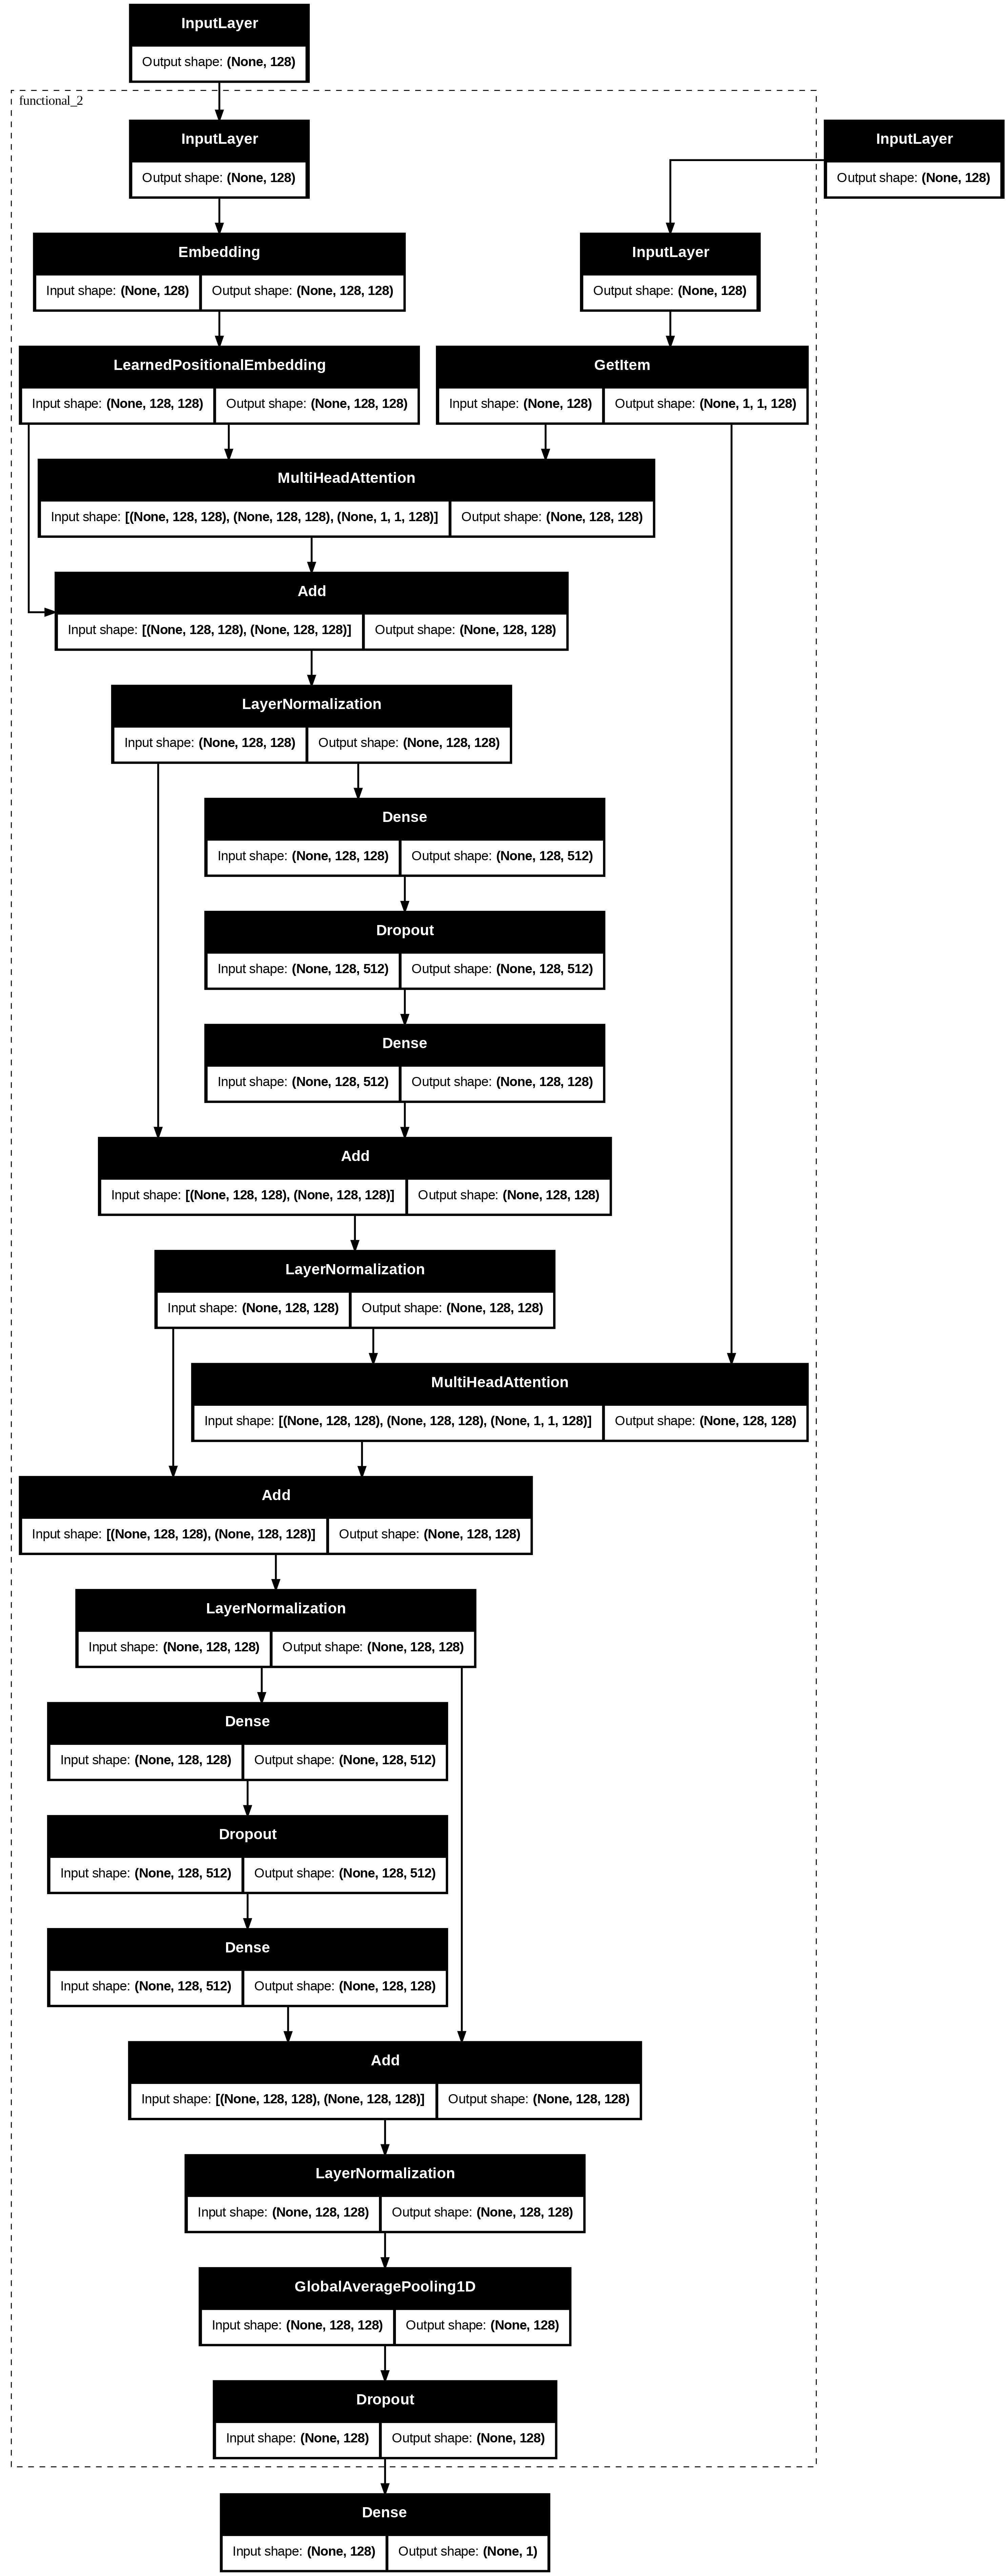

In [62]:
tf.keras.utils.plot_model(model, show_shapes=True, expand_nested=True)

In [63]:
print("Preprocessing Data:")

# Use smaller subsets for testing
train_subset_size = 2000
test_subset_size = 500

# Tokenize the training data
train_texts = dataset_train['text'][:train_subset_size]
train_labels = np.array(dataset_train['label'][:train_subset_size])

train_tokenized = tokenizer(tf.constant(train_texts))
train_input_ids = train_tokenized['input_word_ids'].numpy()
train_attention_mask = train_tokenized['input_mask'].numpy()

# Tokenize the test data
test_texts = dataset_test['text'][:test_subset_size]
test_labels = np.array(dataset_test['label'][:test_subset_size])

test_tokenized = tokenizer(tf.constant(test_texts))
test_input_ids = test_tokenized['input_word_ids'].numpy()
test_attention_mask = test_tokenized['input_mask'].numpy()

# Pad to fixed length
max_seq_length = 128

def pad_sequences(ids, mask, max_length):
    ids = ids[:, :max_length]
    mask = mask[:, :max_length]

    if ids.shape[1] < max_length:
        pad_width = max_length - ids.shape[1]
        ids = np.pad(ids, ((0, 0), (0, pad_width)), mode='constant')
        mask = np.pad(mask, ((0, 0), (0, pad_width)), mode='constant', constant_values=1)

    return ids, mask

train_input_ids, train_attention_mask = pad_sequences(train_input_ids, train_attention_mask, max_seq_length)
test_input_ids, test_attention_mask = pad_sequences(test_input_ids, test_attention_mask, max_seq_length)

print(f"Training Data - input_ids: {train_input_ids.shape}, attention_mask: {train_attention_mask.shape}")
print(f"Test Data - input_ids: {test_input_ids.shape}, attention_mask: {test_attention_mask.shape}")

Preprocessing Data:
Training Data - input_ids: (2000, 128), attention_mask: (2000, 128)
Test Data - input_ids: (500, 128), attention_mask: (500, 128)


### 4.2.6 Training the Model and Performing Quantitative Evaluation

The following function helps us plot the training and validation accuracy and loss after training.

In [64]:
def plot_train_history(hist, metric = 'binary_accuracy'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss Plot
    ax1.plot(hist.history['loss'], 'r--', label='Training Loss')
    ax1.plot(hist.history['val_loss'], 'b-', label='Validation Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy Plot
    ax2.plot(hist.history[metric], 'r--', label='Training Accuracy')
    ax2.plot(hist.history['val_' + metric], 'b-', label='Validation Accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

#### 4.2.6.1 Defining the Training Hyperparameters

In [69]:
# Defining the loss function and the evaluation metric
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = [tf.metrics.BinaryAccuracy()]

In [70]:
# You are encouraged to experiment with tuning the following hyperparameters to handle overfitting/underfitting
epochs = 15
batch_size = 32
lr = 3e-5
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr)

#### 4.2.6.2 Compiling and Training the Model

In [71]:
# Compiling the model using the loss and evaluation metrics
model.compile(optimizer=optimizer,
              loss=loss,
              metrics=metrics)

**TODO:** Make sure to handle any underfitting (*training accuracy should at least be more than 90%*) or overfitting in the training. You can try early stopping and/or regularization methods.

Preprocessing Data for Training:
Preprocessing Training Data:
Preprocessing Test Data:
Training Data Ready: (10000, 128), (10000, 128)
Test Data Ready: (2000, 128), (2000, 128)
Starting Training With Preprocessed Data:
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - binary_accuracy: 1.0000 - loss: 0.0503 - val_binary_accuracy: 1.0000 - val_loss: 5.7784e-04 - learning_rate: 3.0000e-05
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - binary_accuracy: 1.0000 - loss: 5.6837e-04 - val_binary_accuracy: 1.0000 - val_loss: 1.7211e-04 - learning_rate: 3.0000e-05
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - binary_accuracy: 1.0000 - loss: 2.0010e-04 - val_binary_accuracy: 1.0000 - val_loss: 8.0296e-05 - learning_rate: 3.0000e-05
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - binary_accuracy: 1.0000 - loss: 1.0143e-04 - val_binary_accuracy: 1.0000 - val_loss: 4.5105e-05 - learning_rate: 3.0000e-05


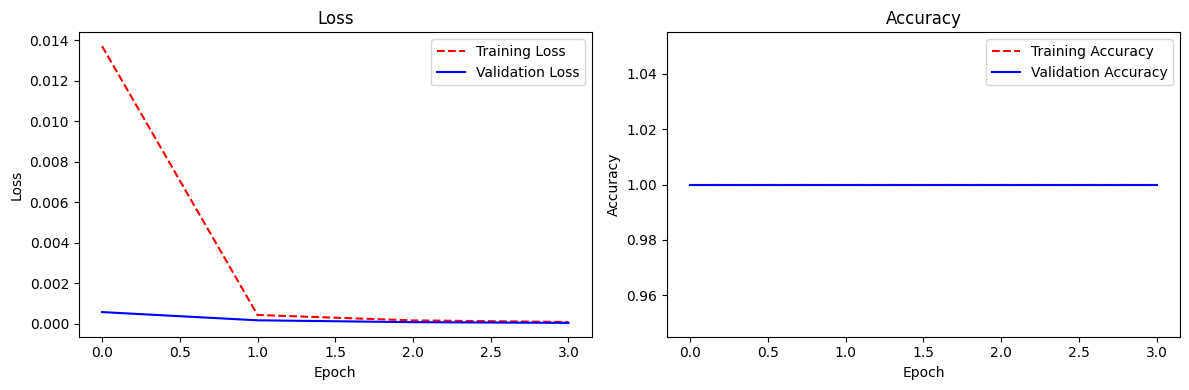

In [72]:
print("Preprocessing Data for Training:")

def preprocess_dataset(texts, labels, tokenizer, max_length=128):
    """Preprocess dataset for training"""
    tokenized = tokenizer(tf.constant(texts))
    input_ids = tokenized['input_word_ids'].numpy()[:, :max_length]
    attention_mask = tokenized['input_mask'].numpy()[:, :max_length]

    # Pad sequences
    if input_ids.shape[1] < max_length:
        pad_width = max_length - input_ids.shape[1]
        input_ids = np.pad(input_ids, ((0, 0), (0, pad_width)), mode='constant')
        attention_mask = np.pad(attention_mask, ((0, 0), (0, pad_width)), mode='constant', constant_values=1)

    return [input_ids, attention_mask], np.array(labels)

print("Preprocessing Training Data:")
train_subset_size = min(10000, len(dataset_train))
X_train, y_train = preprocess_dataset(
    dataset_train['text'][:train_subset_size],
    dataset_train['label'][:train_subset_size],
    tokenizer
)

print("Preprocessing Test Data:")
test_subset_size = min(2000, len(dataset_test))
X_test, y_test = preprocess_dataset(
    dataset_test['text'][:test_subset_size],
    dataset_test['label'][:test_subset_size],
    tokenizer
)

print(f"Training Data Ready: {X_train[0].shape}, {X_train[1].shape}")
print(f"Test Data Ready: {X_test[0].shape}, {X_test[1].shape}")

# Add early stopping to handle overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_binary_accuracy',
    patience=3,
    restore_best_weights=True
)

# Add learning rate reduction
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Starting Training With Preprocessed Data:")
# Running the training and obtaining a plot for it
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

plot_train_history(history, metric='binary_accuracy')

Fixing data loading issue...
Balanced training labels - Pos: 2500, Neg: 2500
Balanced test labels - Pos: 500, Neg: 500
Recompiling the model with stronger regularization and fixed architecture:
New model summary:


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_word_ids      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_mask          │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_8        │ (None, 64)        │  2,061,568 │ input_word_ids[0… │
│ (Functional)        │                   │            │ input_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 64)        │      4,160 │ functional_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 64)        │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_32[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,065,793 (7.88 MB)

 Trainable params: 2,065,793 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

Preprocessing balanced data...
Training data shape: (5000, 128)
Training labels - Pos: 2500, Neg: 2500
Starting training with regularized model on BALANCED data...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - binary_accuracy: 0.5071 - loss: 1.3380 - val_binary_accuracy: 0.5000 - val_loss: 1.2571 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.5045 - loss: 1.2442 - val_binary_accuracy: 0.5000 - val_loss: 1.1810 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.4962 - loss: 1.1734 - val_binary_accuracy: 0.5000 - val_loss: 1.1103 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.5068 - loss: 1.1039 - val_binary_accuracy: 0.5030 - val_loss: 1.0366 - learning_rate: 1.0000e-04
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.5253 - loss: 1.0252 - val_binary_accuracy: 0.6020 - val_loss: 0.9226 - learning_r

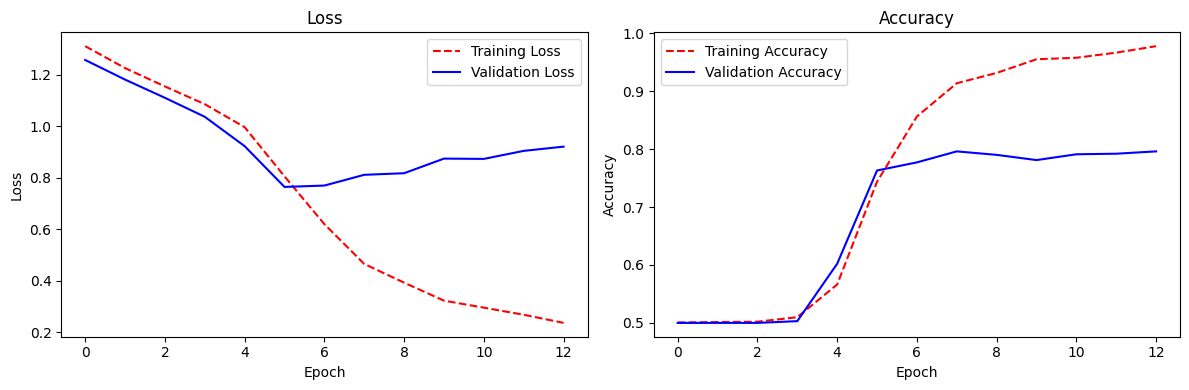

In [76]:
print("Fixing data loading issue...")

def get_balanced_subset(dataset, sample_size=5000):
    """Get a balanced subset with equal positive and negative samples"""
    texts = dataset['text']
    labels = dataset['label']

    # Get indices of positive and negative samples
    pos_indices = [i for i, label in enumerate(labels) if label == 1]
    neg_indices = [i for i, label in enumerate(labels) if label == 0]

    # Take equal samples from each class
    half_size = sample_size // 2
    selected_indices = pos_indices[:half_size] + neg_indices[:half_size]

    balanced_texts = [texts[i] for i in selected_indices]
    balanced_labels = [labels[i] for i in selected_indices]

    return balanced_texts, balanced_labels

# Get balanced data
train_texts_balanced, train_labels_balanced = get_balanced_subset(dataset_train, 5000)
test_texts_balanced, test_labels_balanced = get_balanced_subset(dataset_test, 1000)

print(f"Balanced training labels - Pos: {sum(train_labels_balanced)}, Neg: {len(train_labels_balanced)-sum(train_labels_balanced)}")
print(f"Balanced test labels - Pos: {sum(test_labels_balanced)}, Neg: {len(test_labels_balanced)-sum(test_labels_balanced)}")

class PositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_seq_length, d_model):
        super(PositionEmbedding, self).__init__()
        self.max_seq_length = max_seq_length
        self.d_model = d_model
        self.position_embeddings = Embedding(
            input_dim=max_seq_length,
            output_dim=d_model,
            name='position_embeddings'
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        seq_length = tf.shape(inputs)[1]

        # Create position indices
        positions = tf.range(start=0, limit=seq_length, delta=1)
        positions = tf.tile(tf.expand_dims(positions, 0), [batch_size, 1])

        position_embeddings = self.position_embeddings(positions)
        return inputs + position_embeddings

print("Recompiling the model with stronger regularization and fixed architecture:")

def get_regularized_transformer_encoder(vocab_size=30522, d_model=64, num_heads=4, dff=256, max_seq_length=128):
    input_word_ids = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_word_ids')
    input_mask = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_mask')

    # Word embeddings with smaller dimension
    word_embeddings = Embedding(vocab_size, d_model, name='word_embeddings')(input_word_ids)

    # Add positional embeddings using fixed custom layer
    embeddings = PositionEmbedding(max_seq_length, d_model)(word_embeddings)
    embeddings = Dropout(0.3)(embeddings)  # Increased dropout

    # Create attention mask
    mask = input_mask[:, tf.newaxis, tf.newaxis, :]

    # Transformer block 1 with more regularization
    attn1 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=0.3)(
        embeddings, embeddings, attention_mask=mask
    )
    add1 = Add()([embeddings, attn1])
    norm1 = LayerNormalization(epsilon=1e-6)(add1)

    ff1 = Dense(dff, activation='relu')(norm1)
    ff1 = Dropout(0.4)(ff1)  
    ff1 = Dense(d_model)(ff1)
    add2 = Add()([norm1, ff1])
    out1 = LayerNormalization(epsilon=1e-6)(add2)
    out1 = Dropout(0.3)(out1)  

    # Transformer block 2
    attn2 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=0.3)(
        out1, out1, attention_mask=mask
    )
    add3 = Add()([out1, attn2])
    norm2 = LayerNormalization(epsilon=1e-6)(add3)

    ff2 = Dense(dff, activation='relu')(norm2)
    ff2 = Dropout(0.4)(ff2)
    ff2 = Dense(d_model)(ff2)
    add4 = Add()([norm2, ff2])
    out2 = LayerNormalization(epsilon=1e-6)(add4)
    out2 = Dropout(0.3)(out2)

    # Pool and output
    pooled = GlobalAveragePooling1D()(out2)
    pooled = Dropout(0.5)(pooled)

    return Model(inputs=[input_word_ids, input_mask], outputs=pooled)

# Rebuild the model with regularization
def build_regularized_classifier_model():
    max_seq_length = 128
    input_word_ids = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_word_ids')
    input_mask = Input(shape=(max_seq_length,), dtype=tf.int32, name='input_mask')

    encoder = get_regularized_transformer_encoder(max_seq_length=max_seq_length)
    encoder_output = encoder([input_word_ids, input_mask])

    hidden = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(encoder_output)
    hidden = Dropout(0.5)(hidden)
    output = Dense(1, activation=None, name='output')(hidden)

    return Model(inputs=[input_word_ids, input_mask], outputs=output)

# Create new regularized model
regularized_model = build_regularized_classifier_model()

# Compile with different hyperparameters
regularized_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy()]
)

print("New model summary:")
regularized_model.summary()

print("Preprocessing balanced data...")
X_train_balanced, y_train_balanced = preprocess_dataset(train_texts_balanced, train_labels_balanced, tokenizer)
X_val_balanced, y_val_balanced = preprocess_dataset(test_texts_balanced, test_labels_balanced, tokenizer)

print(f"Training data shape: {X_train_balanced[0].shape}")
print(f"Training labels - Pos: {sum(y_train_balanced)}, Neg: {len(y_train_balanced)-sum(y_train_balanced)}")

# Stronger callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_binary_accuracy',
    patience=5,
    restore_best_weights=True,
    min_delta=0.01
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Starting training with regularized model on BALANCED data...")
# Train with more epochs but stronger regularization
history_regularized = regularized_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_data=(X_val_balanced, y_val_balanced),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

print("Training completed with regularization")
plot_train_history(history_regularized, metric='binary_accuracy')

# Update the global model variable to use the regularized one
model = regularized_model

### 4.2.7 Qualitative Evaluation

In [77]:
# This function converts the output model probabiltiy into a sentiment (Positive or Negative)
def get_sentiment(probability_positive):
  if probability_positive > 0.5:
    return "Positive"
  else:
    return "Negative"

In [78]:
def predict_sentiment(text, model, tokenizer, max_length=128):
    """Predict sentiment for a single text"""
    # Tokenize
    tokenized = tokenizer([text])
    input_ids = tokenized['input_word_ids'].numpy()[:, :max_length]
    attention_mask = tokenized['input_mask'].numpy()[:, :max_length]

    # Pad again
    if input_ids.shape[1] < max_length:
        pad_width = max_length - input_ids.shape[1]
        input_ids = np.pad(input_ids, ((0, 0), (0, pad_width)), mode='constant')
        attention_mask = np.pad(attention_mask, ((0, 0), (0, pad_width)), mode='constant', constant_values=1)

    # Predict
    logits = model.predict([input_ids, attention_mask], verbose=0)
    probability_positive = 1 / (1 + np.exp(-logits[0][0]))

    return probability_positive

Let's check the model's output compared to random review samples from the testing data. You can run the following cell multiple times to see different examples!

In [81]:
# Randomly select a test review and check the model's output on it
print("Qualitative Evaluation - Testing on random samples:")
print("=" * 100)

for i in range(10):
    random_id = np.random.randint(0, len(dataset_test))
    test_review = dataset_test['text'][random_id]
    test_label = dataset_test['label'][random_id]
    print(f"\nSample {i+1}:")
    print("Review:", test_review[:200] + "..." if len(test_review) > 200 else test_review)
    print("Ground Truth Sentiment:", get_sentiment(test_label))

    # Prediction probability of the Positive review
    probability_positive = predict_sentiment(test_review, model, tokenizer)
    probability_negative = 1 - probability_positive
    print("Predicted Sentiment:", get_sentiment(probability_positive))
    print("Prediction Probability: Positive({:.4f}), Negative({:.4f})".format(probability_positive, probability_negative))
    print("Correct:", "✓" if get_sentiment(test_label) == get_sentiment(probability_positive) else "✗")
    print("-" * 100)

Qualitative Evaluation - Testing on random samples:

Sample 1:
Review: One type of western I greatly enjoy is when the apparently weak, which is reluctant to fight and answer the challenge of the strong, finally decides there is no other way. There is a great moment in t...
Ground Truth Sentiment: Positive
Predicted Sentiment: Positive
Prediction Probability: Positive(0.9950), Negative(0.0050)
Correct: ✓
----------------------------------------------------------------------------------------------------

Sample 2:
Review: A great gangster flick, with brilliant performances by well-known actors with great action scenes? Well, not this one.<br /><br />It's rather amazing to see such a wide cast of well-known actors, that...
Ground Truth Sentiment: Negative
Predicted Sentiment: Positive
Prediction Probability: Positive(0.9938), Negative(0.0062)
Correct: ✗
----------------------------------------------------------------------------------------------------

Sample 3:
Review: If not the best

Final Evaluation on Balanced Test Set:
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.8137 - loss: 0.7195
Test Loss: 0.8114
Test Accuracy: 0.7960

Training Summary:
Training completed after 13 epochs
Final Training Accuracy: 0.9776
Final Validation Accuracy: 0.7960
Best Validation Accuracy: 0.7960


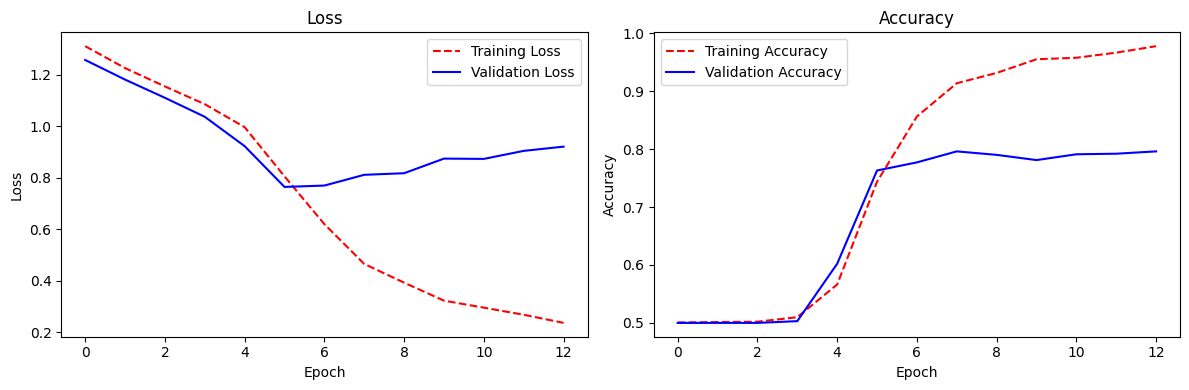

In [82]:
print("Final Evaluation on Balanced Test Set:")
test_loss, test_accuracy = model.evaluate(X_val_balanced, y_val_balanced, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

final_epoch = len(history_regularized.history['loss'])
print(f"\nTraining Summary:")
print(f"Training completed after {final_epoch} epochs")
print(f"Final Training Accuracy: {history_regularized.history['binary_accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_regularized.history['val_binary_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history_regularized.history['val_binary_accuracy']):.4f}")

plot_train_history(history_regularized, metric='binary_accuracy')

## 4.3 Conclusion

That's it! Congratulations on training a transformer-based sentiment analysis model.

Make sure you deliver all the requirements for the submission and to keep the outputs in the notebook!